# Predict sentinel species probability
author: Iris

[Report(Google doc)](https://docs.google.com/document/d/1SzrU_hrSxSpVCK62aJ9SV0rp09Icu9gbRtjF1pKIr1c/edit?usp=sharing)

## Challenge  
1. Most of the plot we made is related to simulation, however, I can't use any feature related to simulation because it may lead to data leakage.
2. I create some features which are not related to simulation, but I don't think it's convincing enough now.

## Feature's definition:
1. **NocturnalBias**: the ratio of nighttime to daytime activity  
Why it matters: many sentinel-like species maintain vigilance or calling at specific periods.  
Contribution/direction: a stable bias toward certain periods suggests structured vigilance rather than ransome activiti; tipically **positive** weight. 
2. **TimeConcentration**: how concentrated the activity times are over 24h (mean resultant length R)  
Why it matters: true sentinels show consistent time windows of vigilance; noise-driven speices look diffuse.  
Contribution/direction: higher R = more stable schedule, reducing false positives from random spikes; **typically positive**.
3. **HourlyEntropy** : entropy of hourly distribution; **lower = more regular**.  
Why it matters: regular temporal patterns are typical of role-structured species (e.g., vigilance).  
Contribution/direction: lower entropy → more predictable timing; overlaps with concentration but not identical; **typically negative weight**.
4. **~~Circadian profile~~** *deleted because It's redundant with TimeConcentation*: daily phase(when activity peaks) and amplitude(how strong day-night contrast is)  
Why it matters: sentinels may peak at human-active times; phase/amplitude are interpretable "temporal fingerprints"  
Contribution/direction: complements concentration by encoding when and how strong; generally positive, phase-dependent.3. **~~Circadian profile~~** *deleted because It's redundant with TimeConcentation*: daily phase(when activity peaks) and amplitude(how strong day-night contrast is)  
Why it matters: sentinels may peak at human-active times; phase/amplitude are interpretable "temporal fingerprints"  
Contribution/direction: complements concentration by encoding when and how strong; generally positive, phase-dependent.
5. **~~Call activity~~** *deleted because call rate is based on has_onset and it's an acoustic features, which are already input in human presence project*: baseline calling intensity and stability independent of events (after per-device normalization).  
Why it matters: sentinels may sustain higher rates in key windows with tighter variance; also reflects detectability.  
Contribution/direction: adds reliability/detectability and rhythm stability; mean often positive, excessive variance negative.
6. **~~Acoustic texture~~** *deleted because all acoustic features are already input in human presence project*: timbral properties (brightness, spectral spread, transients) as event-free baselines.  
Why it matters: vigilance calls often show distinctive timbre (e.g., sharp transients, high-freq energy).  
Contribution/direction: complements timing by adding what it sounds like; typically positive after site-specific calibration.

# Load Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create features

In [7]:
# df = pd.read_csv("/Users/hsuan/find_job/unpaid_intern/Kwf/AI/human/sliding_window_acoustic.csv")
df = pd.read_csv("D:/Kashmir_World_Foundation/sliding_window_acoustic.csv", dtype={'75': int}, low_memory=False)

In [8]:
#df['Tempo (BPM)'] = df['Tempo (BPM)'].str.strip("[]").astype(float)
df.isna().sum()[df.isna().sum() > 0]

Sim Type             762708
Sim Relative Time    762708
dtype: int64

In [9]:
df_val = df.copy()

In [10]:
# -----------------------------
# 0) Column assumptions (rename here if needed)
# -----------------------------
species_col      = 'species'
device_col       = 'recorder_id'
hour_col         = 'Datetime_hour'        # 0–23
sim_type_col     = 'Sim Type'             # OPTIONAL: used only for validation split (baseline vs simulation)

# -----------------------------
# 2) Coverage filter: keep only (species, device) with enough clips
#    Why do we use Species × Device? Because the sample size for the same species can be very different across devices.
#    Devices with very few samples will make that species’ statistics highly biased/unstable
#    so we first filter at the device level and then aggregate up to the species level for more stable results
# -----------------------------
min_clips = 10
pair_counts = df.groupby([species_col, device_col]).size().reset_index(name='n')
valid_pairs = pair_counts.query('n >= @min_clips')[[species_col, device_col]]
df_f = df.merge(valid_pairs, on=[species_col, device_col], how='inner')

# -----------------------------
# 3) Safe features (NO event-based input)
#    3.1 NocturnalBias   (smoothed night ratio)
#    3.2 TimeConcentration (circular R)
#    3.3 HourlyEntropy   (predictability of hour-distribution)
#    3.4 Acoustic baselines (per-species stats of z-scored acoustics)
# -----------------------------
def nocturnal_bias(s):
    # night = 19:00–04:59
    night_mask = (s[hour_col] >= 19) | (s[hour_col] < 5)
    n_night = night_mask.sum()
    n_day   = len(s) - n_night
    # Beta(1,1) smoothing → avoid 0/1 extremes
    return (n_night + 1) / (n_night + n_day + 2)

def time_concentration(s):
    theta = 2*np.pi*(s[hour_col] / 24.0)
    C, S = np.cos(theta).mean(), np.sin(theta).mean()
    return float(np.hypot(C, S))  # mean resultant length R ∈ [0,1]

def hourly_entropy(s):
    p = s[hour_col].value_counts(normalize=True).reindex(range(24), fill_value=0.0)
    p = p + 1e-12
    return float(-(p*np.log(p)).sum())  # lower = more concentrated/regular

# time-related features
time_feats = (
    df_f.groupby(species_col)
        .apply(lambda g: pd.Series({
            'NocturnalBias'   : nocturnal_bias(g),
            'TimeConcentration': time_concentration(g),
            'HourlyEntropy'   : hourly_entropy(g)
        }))
        .reset_index()
)
# Circadian profile

# merge to one safe feature table
safe_features = (
    time_feats
)

# -----------------------------
# 4) Scale features BEFORE combining (fixes "all probabilities are 1.0" issue)
#    We apply z-scoring to each feature across species so that the weights are comparable and the sigmoid won’t saturate.
# -----------------------------
combine_cols = ['NocturnalBias','TimeConcentration','HourlyEntropy']

for c in combine_cols:
    mu = safe_features[c].mean()
    sd = safe_features[c].std(ddof=0) + 1e-9
    safe_features[c+'_z'] = (safe_features[c] - mu) / sd

C:\Users\jacky\AppData\Local\Temp\ipykernel_28804\2077939432.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


# Model

### **Revise weights here**

In [11]:
# Manual weights (can be slightly adjusted based on complementarity; this is just an example).
# --- How to tune weights (w) ---
# 0) Weights do NOT have to sum to 1. Keep z within ~[-2, +2] so σ(z) is not saturated.
# 1) Only weight z-scored features (*_z) so magnitudes are comparable.
# 2) Signs:
#    - NocturnalBias_z:   positive
#    - TimeConcentration_z: positive
#    - HourlyEntropy_z:   negative (higher entropy = less sentinel-like)
# 3) Sanity-check: z percentiles ~ [-2, 0, +2]. If probs ≈1.0 → weights too big; if ≈0.5 → too small/canceling.
w = {
    'NocturnalBias_z'    : 0.25,
    'TimeConcentration_z': 0.25,
    'HourlyEntropy_z'    : -0.15,  # Higher regularity (lower entropy) is more sentinel-like → assign a negative weight.
}


z = (
    w['NocturnalBias_z']     * safe_features['NocturnalBias_z'] +
    w['TimeConcentration_z'] * safe_features['TimeConcentration_z'] +
    w['HourlyEntropy_z']     * safe_features['HourlyEntropy_z']
)

# logistic to 0–1
sentinel_prob = 1.0 / (1.0 + np.exp(-z))
safe_features['SentinelProb'] = sentinel_prob.clip(0, 1)
# The safe_features table is exactly what you should feed into the downstream simulation prediction model
# (it does not contain any event-based information).


In [12]:
safe_features

,species,NocturnalBias,TimeConcentration,HourlyEntropy,NocturnalBias_z,TimeConcentration_z,HourlyEntropy_z,SentinelProb
0,Amazilia tzacatl_Rufous-tailed Hummingbird,0.010000,0.814959,1.369039,-0.358613,0.102534,0.075334,0.481179
1,Amazona autumnalis_Red-lored Parrot,0.001923,0.998674,0.169658,-0.396311,1.000241,-1.616391,0.597111
2,Amazona farinosa_Mealy Parrot,0.000321,0.900129,0.888099,-0.403789,0.518713,-0.603031,0.529761
3,Ara ambiguus_Great Green Macaw,0.062500,0.991445,0.693147,-0.113578,0.964917,-0.878010,0.585292
4,Ara macao_Scarlet Macaw,0.000296,0.617440,2.418027,-0.403907,-0.862625,1.554930,0.365894
...,...,...,...,...,...,...,...,...
159,Volatinia jacarina_Blue-black Grassquit,0.062500,0.991445,0.693147,-0.113578,0.964917,-0.878010,0.585292
160,Xenops minutus_Plain Xenops,0.003086,0.725830,1.487576,-0.390881,-0.332986,0.242530,0.445876
161,Xiphorhynchus lachrymosus_Black-striped Woodcr...,0.002841,0.875626,1.428820,-0.392027,0.398978,0.159654,0.494448
162,Xiphorhynchus susurrans_Cocoa Woodcreeper,0.001779,0.580343,1.741890,-0.396981,-1.043892,0.601240,0.389265


In [13]:
safe_features['SentinelProb'].describe()
safe_features['SentinelProb'].value_counts(bins=10, sort=False)


(0.287, 0.338]     5
(0.338, 0.388]    16
(0.388, 0.438]    26
(0.438, 0.488]    39
(0.488, 0.537]    24
(0.537, 0.587]    24
(0.587, 0.637]    20
(0.637, 0.687]     4
(0.687, 0.737]     3
(0.737, 0.787]     3
Name: count, dtype: int64

In [14]:
safe_features[safe_features['SentinelProb'] == safe_features['SentinelProb'].max()]

,species,NocturnalBias,TimeConcentration,HourlyEntropy,NocturnalBias_z,TimeConcentration_z,HourlyEntropy_z,SentinelProb
156,Tyto alba_Barn Owl,0.968023,0.968076,1.016263,4.112793,0.850729,-0.422256,0.786544


# Export data

In [16]:
safe_features.to_csv('new_feature.csv', index=False)

# Evaluation <- abandon this section
since I use simulation or not to validate it. However, simulation and setinel species prob are highly correlated, so validating it is too complicated. Therefore, I abandon it.

In [ ]:
# don't run this code more than twice. Otherwise, you'll get error messages
df_val = (
    df_val.explode(['Sim Type','Sim Relative Time'])
      .rename(columns={'Sim Type':'sim_name',
                       'Sim Relative Time':'sim_rel_time'})
      .reset_index(drop=True)
)

In [ ]:
# -----------------------------
# 5) (Optional) DISTRIBUTIONAL VALIDATION — baseline vs simulation
#    Use this only to check/validate the red vs. blue differences; do not feed it into the downstream model to avoid leakage.
# -----------------------------

presence_tags = {'Human Presence on Trail', 'Human Presence off Trail'}
event_tags     = set(df_val['sim_name'].dropna()) - presence_tags

df_val['sim_type'] = np.select(
    [df_val['sim_name'].isin(presence_tags),
     df_val['sim_name'].isin(event_tags)],
    ['presence','event'],
    default='none')

def is_sim_row(row):
    rel = row['sim_rel_time']
    if pd.isna(rel): 
        return False
    if row['sim_type'] == 'presence':
        return abs(rel) <= 900             
    if row['sim_type'] == 'event':
        return (0 <= rel <= 300)          
    return False

df_val['sim_flag'] = df_val.apply(is_sim_row, axis=1)
df_val['sim_lbl' ] = df_val['sim_flag'].map({False:'baseline', True:'simulation'})


import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, wasserstein_distance

# === column names ===
species_col = 'species'
device_col  = 'recorder_id'
sim_lbl_col = 'sim_lbl'   

# double check if sim_lbl includes baseline/simulation only
assert set(df_val[sim_lbl_col].dropna().astype(str).str.lower().unique()) <= {'baseline','simulation'}


non_feature_cols = {species_col, device_col, sim_lbl_col, 'Datetime_hour', 'window_duration'}
acoustic_cols = [
    c for c in df_val.columns
    if (c not in non_feature_cols) and (np.issubdtype(df_val[c].dtype, np.number))
]

# get baseline/simulation（use sim_lbl）
def split_baseline_sim(df_sub: pd.DataFrame):
    lbl = df_sub[sim_lbl_col].astype(str).str.lower()
    base = df_sub[lbl == 'baseline']
    sim  = df_sub[lbl == 'simulation']
    return base, sim

# Cliff's delta：P(a>b)-P(a<b)
def cliffs_delta(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sign(a[:, None] - b[None, :]).sum() / (len(a)*len(b)))

def quantile_shifts(a: np.ndarray, b: np.ndarray, qs=(0.5, 0.9)):
    qa = np.quantile(a, qs); qb = np.quantile(b, qs)
    return {f'dQ{int(q*100)}': float(qb_i - qa_i) for qb_i, qa_i, q in zip(qb, qa, qs)}

# for single (species, device) group calculate acoustic data's distance
def per_pair_distances(g: pd.DataFrame, min_per_class: int = 5):
    base, sim = split_baseline_sim(g)
    # If the species doesn't have baseline and simulation at the same time in this device, we skip
    if (len(base) < min_per_class) or (len(sim) < min_per_class):
        return None

    out = {}
    for c in acoustic_cols:

        a = base[c].dropna().values
        b = sim[c].dropna().values
        if (len(a) < min_per_class) or (len(b) < min_per_class):
            continue

        # KS (any difference in distribution shape), Wasserstein (location + shape), Cliff’s δ (ordinal effect size), and quantile differences.
        out[f'{c}_KS']    = float(ks_2samp(a, b, mode='auto').statistic)
        out[f'{c}_Wass']  = float(wasserstein_distance(a, b))
        out[f'{c}_Cliff'] = cliffs_delta(a, b)
        out.update({f'{c}_{k}': v for k, v in quantile_shifts(a, b, qs=(0.5, 0.9)).items()})

    return pd.Series(out) if out else None

# 1) using (species, recorder_id) calculate distance between「red vs blue」distribution
dist_pair = (
    df_val
    .groupby([species_col, device_col], group_keys=False)
    .apply(per_pair_distances)            
    .dropna(how='all')                    
    .reset_index()
)

# 2) get median
dist_species = (
    dist_pair
    .groupby(species_col)
    .median(numeric_only=True)
    .reset_index()
)




In [ ]:
dist_species = dist_pair.groupby("species").median(numeric_only=True).reset_index()

In [ ]:
validation_table = (
    safe_features
    .merge(dist_species, on='species', how='inner')
)


In [ ]:
# Extract all Wasserstein columns (you can switch to KS or Cliff if you prefer).）

wass_cols = [c for c in validation_table.columns if c.endswith('_Wass')]


ks_cols = [c for c in validation_table.columns if c.endswith('_KS')]

# Create an “average shift index” to make plotting easier.
validation_table['Shift_Wass_mean'] = validation_table[wass_cols].mean(axis=1)


**Shift_Wass_mean**: For each species, Shift_Wass_mean is the average Wasserstein distance between the baseline and simulation distributions across all acoustic features.
Intuitively, it measures how much the species’ acoustic behavior changes when humans are present compared to normal baseline conditions.

In [ ]:
cols_of_interest = ['SentinelProb'] + [
    c for c in validation_table.columns if c.endswith('_Wass') or c.endswith('_KS')
]
validation_table[cols_of_interest].corr()


,SentinelProb,segment_id_KS,segment_id_Wass,start_time_KS,start_time_Wass,end_time_KS,end_time_Wass,onset_confidence_KS,onset_confidence_Wass,preliminary_rms_KS,...,Temperature_KS,Temperature_Wass,Windspeed_KS,Windspeed_Wass,Precipitation_KS,Precipitation_Wass,Humidity_KS,Humidity_Wass,Weathercode_KS,Weathercode_Wass
SentinelProb,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.127137,-0.100620,0.229556,...,0.114595,-0.187083,-0.035729,-0.050589,-0.067856,-0.170556,0.065478,-0.103650,-0.013905,-0.074460
segment_id_KS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id_Wass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_time_KS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_time_Wass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Precipitation_Wass,-0.170556,NaN,NaN,NaN,NaN,NaN,NaN,0.589431,0.666164,0.383529,...,-0.011135,0.361704,0.003836,-0.130650,0.735340,1.000000,-0.025899,0.423551,0.152396,0.637714
Humidity_KS,0.065478,NaN,NaN,NaN,NaN,NaN,NaN,0.133118,0.125027,0.097980,...,0.970947,0.281791,0.605271,0.260447,0.114534,-0.025899,1.000000,0.416853,0.363141,0.145790
Humidity_Wass,-0.103650,NaN,NaN,NaN,NaN,NaN,NaN,0.210717,0.229986,0.283155,...,0.376712,0.880359,0.290810,0.335209,0.552746,0.423551,0.416853,1.000000,0.186583,0.455173
Weathercode_KS,-0.013905,NaN,NaN,NaN,NaN,NaN,NaN,0.273082,0.342759,0.284744,...,0.359107,0.082694,0.135537,0.050364,0.238639,0.152396,0.363141,0.186583,1.000000,0.479439


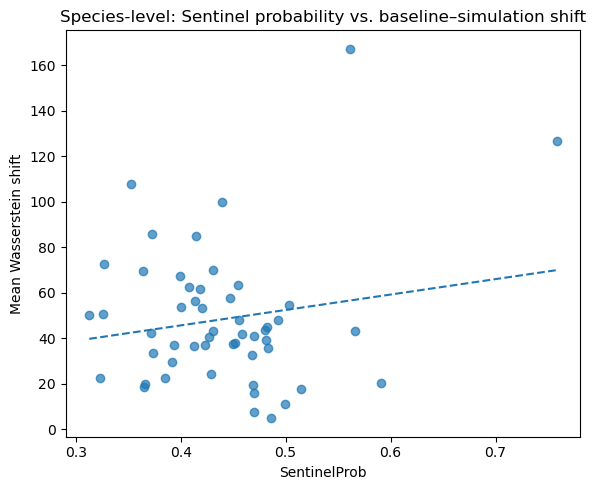

In [ ]:
plt.figure(figsize=(6, 5))

x = validation_table['SentinelProb']
y = validation_table['Shift_Wass_mean']

plt.scatter(x, y, alpha=0.7)
plt.xlabel('SentinelProb')
plt.ylabel('Mean Wasserstein shift')
plt.title('Species-level: Sentinel probability vs. baseline–simulation shift')

# Add a simple linear regression line (for visual guidance only).
if len(validation_table) >= 2:
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = coef[0] * x_line + coef[1]
    plt.plot(x_line, y_line, linestyle='--')

plt.tight_layout()
plt.show()


In [ ]:
corr = validation_table[['SentinelProb', 'Shift_Wass_mean']].corr(method='spearman').iloc[0, 1]
print('Spearman correlation between SentinelProb and Shift_Wass_mean:', corr)


Spearman correlation between SentinelProb and Shift_Wass_mean: -0.16221292580893024


In [ ]:
q_low  = validation_table['SentinelProb'].quantile(0.33)
q_high = validation_table['SentinelProb'].quantile(0.67)

def sentinel_group(p):
    if p <= q_low:
        return 'low'
    elif p >= q_high:
        return 'high'
    else:
        return 'mid'

validation_table['SentinelGroup'] = validation_table['SentinelProb'].apply(sentinel_group)


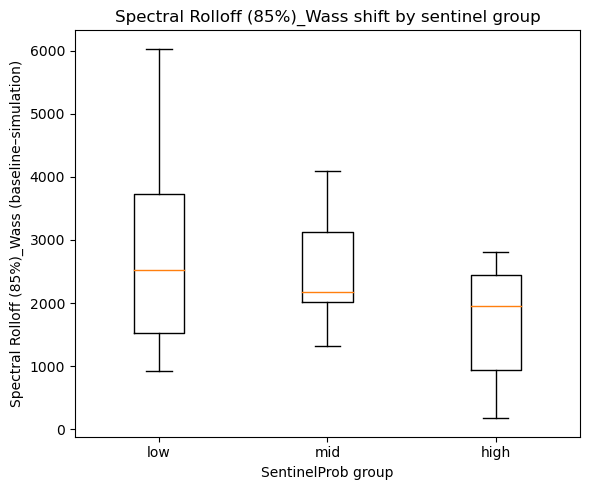

In [ ]:
metric = 'Spectral Rolloff (85%)_Wass'  # change the column you want to validate

data_low  = validation_table.loc[validation_table['SentinelGroup'] == 'low',  metric]
data_mid  = validation_table.loc[validation_table['SentinelGroup'] == 'mid',  metric]
data_high = validation_table.loc[validation_table['SentinelGroup'] == 'high', metric]

plt.figure(figsize=(6, 5))
plt.boxplot(
    [data_low, data_mid, data_high],
    labels=['low', 'mid', 'high'],
    showfliers=False
)
plt.xlabel('SentinelProb group')
plt.ylabel(metric + ' (baseline–simulation)')
plt.title(f'{metric} shift by sentinel group')
plt.tight_layout()
plt.show()


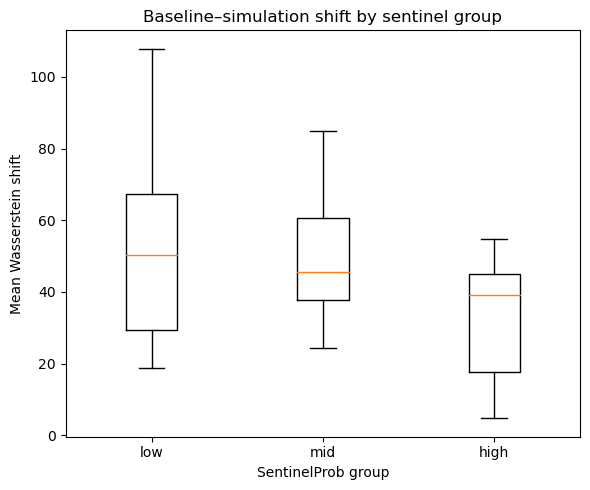

In [ ]:
metric = 'Shift_Wass_mean'
data_low  = validation_table.loc[validation_table['SentinelGroup'] == 'low',  metric]
data_mid  = validation_table.loc[validation_table['SentinelGroup'] == 'mid',  metric]
data_high = validation_table.loc[validation_table['SentinelGroup'] == 'high', metric]

plt.figure(figsize=(6, 5))
plt.boxplot(
    [data_low, data_mid, data_high],
    labels=['low', 'mid', 'high'],
    showfliers=False
)
plt.xlabel('SentinelProb group')
plt.ylabel('Mean Wasserstein shift')
plt.title('Baseline–simulation shift by sentinel group')
plt.tight_layout()
plt.show()


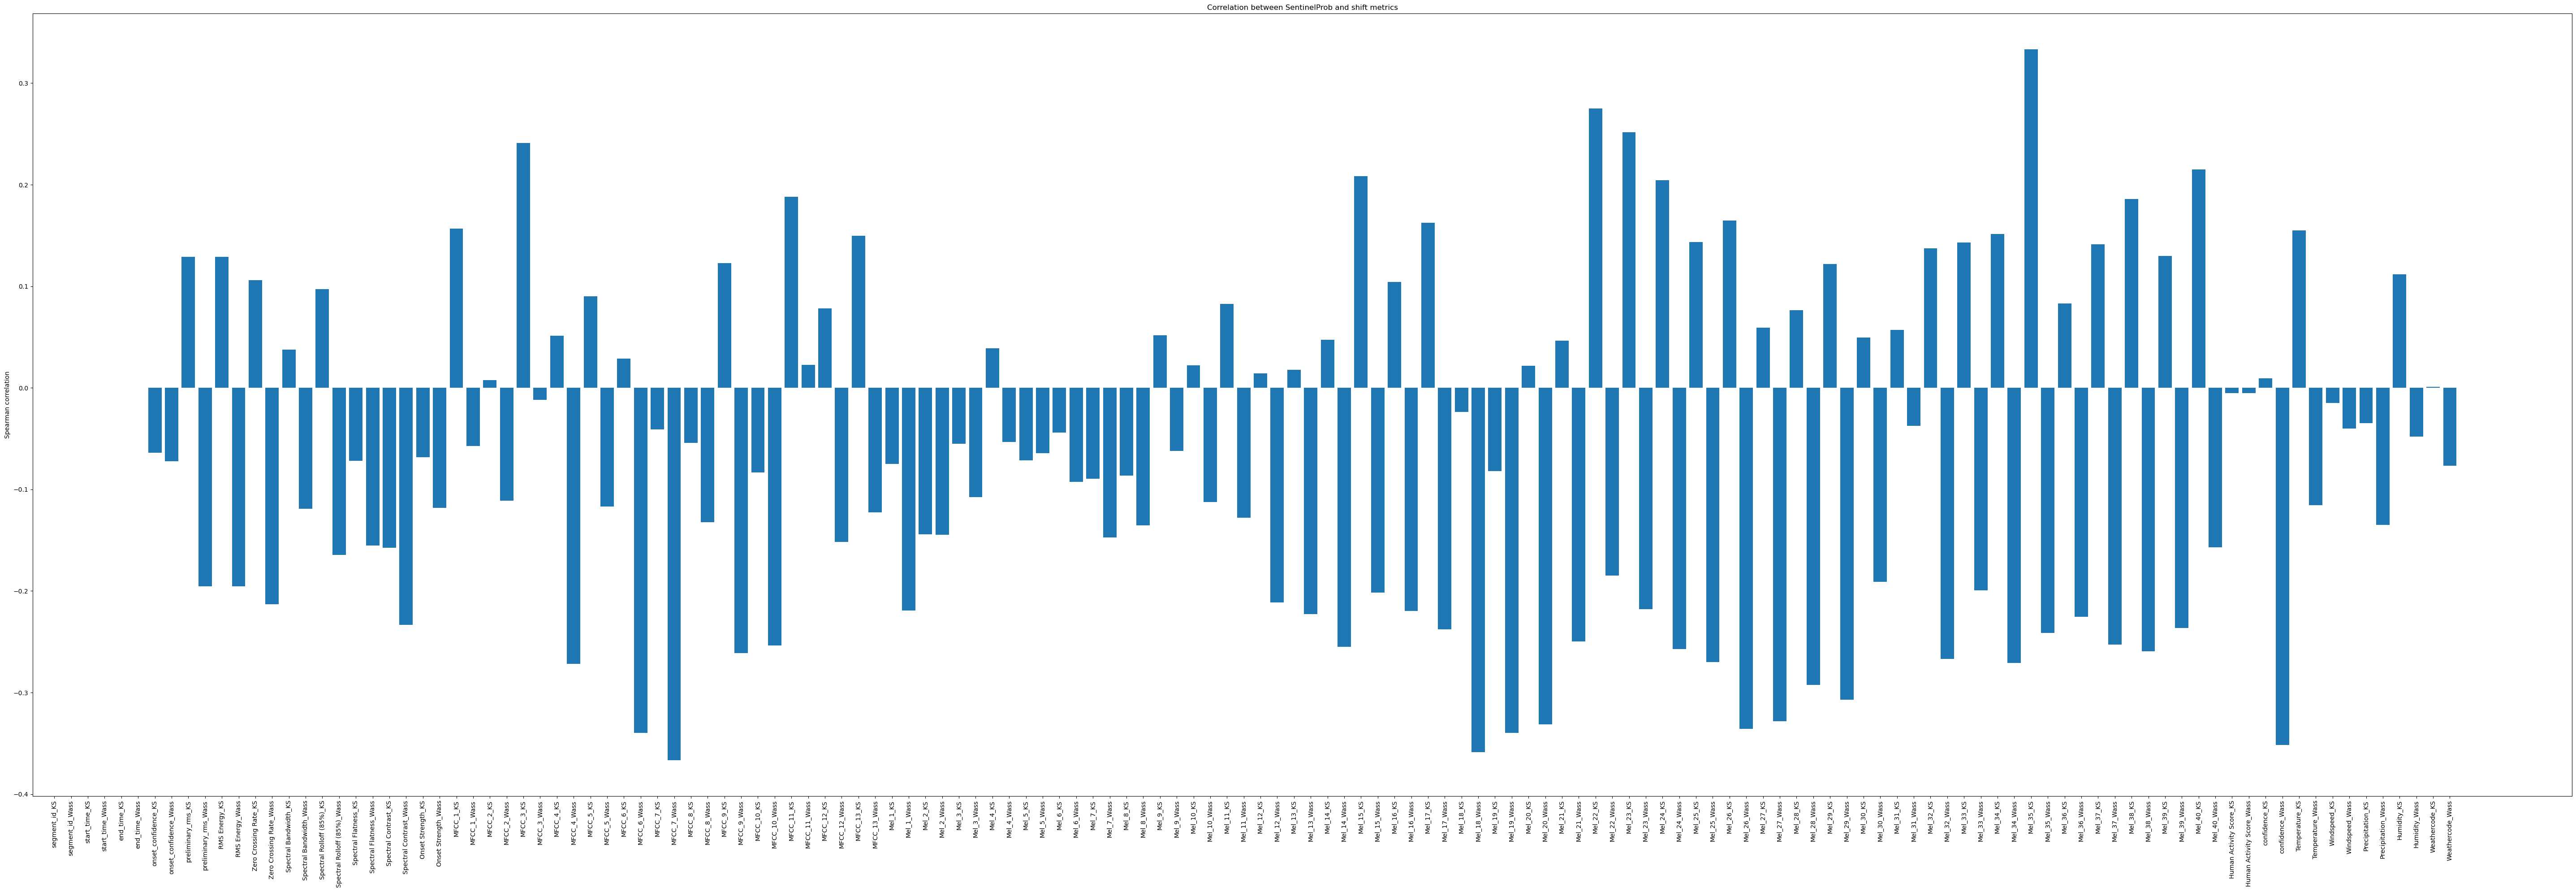

In [ ]:
# Only select the shift columns you care about, for example all Wasserstein + KS.
shift_cols = [c for c in validation_table.columns 
              if c.endswith('_Wass') or c.endswith('_KS')]

corr_df = validation_table[['SentinelProb'] + shift_cols].corr(method='spearman')

# Since corr_df is (1+N) × (1+N), we only look at the first row
# (the correlations between SentinelProb and all other variables)
sentinel_corr = corr_df.loc['SentinelProb', shift_cols]

plt.figure(figsize=(max(6, len(shift_cols) * 0.4), 20))
plt.bar(range(len(shift_cols)), sentinel_corr.values)
plt.xticks(range(len(shift_cols)), shift_cols, rotation=90)
plt.ylabel('Spearman correlation')
plt.title('Correlation between SentinelProb and shift metrics')
plt.tight_layout()
plt.show()
